In [6]:
import numpy as np
import joblib 
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


import warnings
warnings.filterwarnings("ignore")

In [7]:
model = load_model("../models/Effnet_model.keras")
label_encoder = joblib.load("../models/label_encoder.joblib")

In [19]:
img1 = "../test image/Image_73.jpg"
img2 = "../test image/Image_74.jpg"

In [22]:
img = image.load_img(img2, target_size=(224, 224))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)
predicted_class = np.argmax(prediction)

class_name = label_encoder.inverse_transform([predicted_class])[0]
confidence = np.max(prediction)

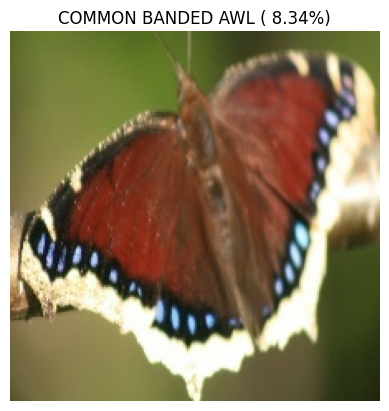

Prediction: COMMON BANDED AWL
Confidence: 8.34%


In [23]:
plt.imshow(img)
plt.axis("off")
plt.title(f"{class_name} ({confidence: .2%})")
plt.show()

print("Prediction:", class_name)
print("Confidence:", f"{confidence:.2%}")